# Grupowanie hierachiczne

W eksploracji danych i statystyce klastrowanie hierarchiczne to metoda analizy klastrów, która ma na celu zbudowanie hierarchii klastrów. Strategie hierarchicznego grupowania generalnie dzielą się na dwie kategorie:

* **Aglomeracyjne (aglomerative)**: Jest to podejście „oddolne”: na początek każda obserwacja tworzy pojedyńczą grupę, a następnie pary skupień są łączone w miarę przesuwania się w górę hierarchii.
* **Deglomeracyjne (divisive)**: Jest to podejście „z góry na dół”: na początek wszystkie obserwacje tworzą jedną grupę, a następnie grupy są dzielone rekurencyjnie w miarę przesuwania się w dół hierarchii.

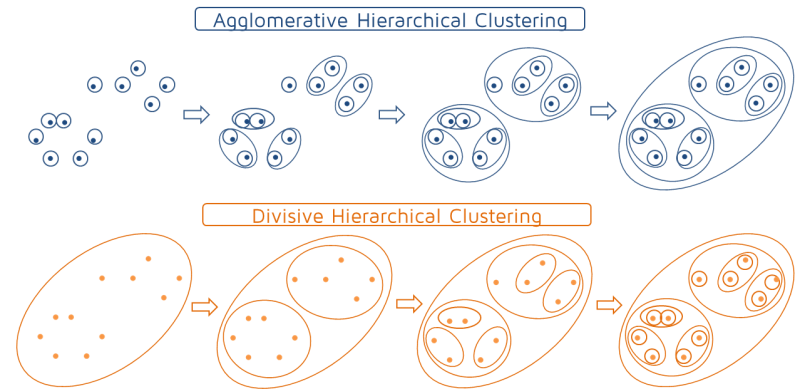

Obrazek skopiowany z https://quantdare.com/hierarchical-clustering/

## Metody aglomeracyjne

Aby zdecydować, które skupienia należy połączyć, wymagana jest miara bliskości zbiorów obserwacji. Dla pojedyńczych obserwacji miarą bliskości jest odległość. Bliskość dwóch zbiorów obserwacji, zwana metodą połączenia (**linkage**), można określić na wiele sposobów.    

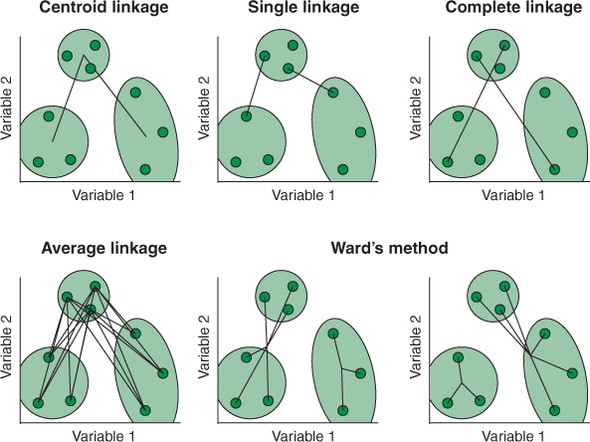

Połączenie Ward’a **Ward linkage**

$$
\frac{|A| \cdot|B|}{|A \cup B|}\left\|\mu_A-\mu_B\right\|^2=\sum_{x \in A \cup B}\left\|x-\mu_{A \cup B}\right\|^2-\sum_{x \in A}\left\|x-\mu_A\right\|^2-\sum_{x \in B}\left\|x-\mu_B\right\|^2
$$

Kompletne połączenie **complete-linkage**
$$
\max _{a \in A, b \in B} d(a, b)
$$

Średnie połączenie **average linkage** 
$$
\frac{1}{|A| \cdot|B|} \sum_{a \in A} \sum_{b \in B} d(a, b)
$$

Pojedyncze połączenie **single-linkage**
$$
\min _{a \in A, b \in B} d(a, b)
$$

### Przykład

Zaczynamy od wygenerowania danych w dwóch wymiarach składających się z trzech grup. Celem jest odkrycie tych grup przez algorytm.

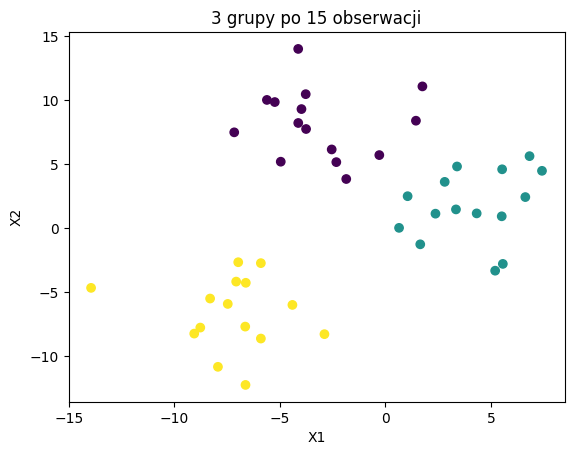

In [20]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

random_seed = 42

X, y = make_blobs(n_samples=45, centers=3, cluster_std=2.7, random_state=random_seed)


plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('3 grupy po 15 obserwacji')

# Show the plot
plt.show()

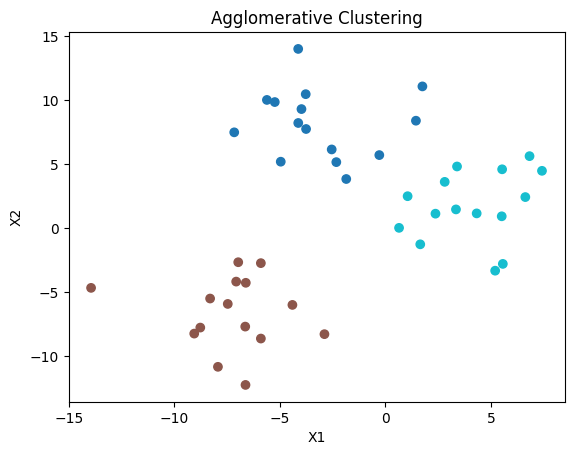

In [22]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering


# linkage = 'ward' (wartość domyślna), ‘complete’, ‘average’, ‘single’
clustering = AgglomerativeClustering(n_clusters=3, linkage = 'ward') 
cluster_labels = clustering.fit_predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='tab10')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Agglomerative Clustering')

# Show the plot
plt.show()


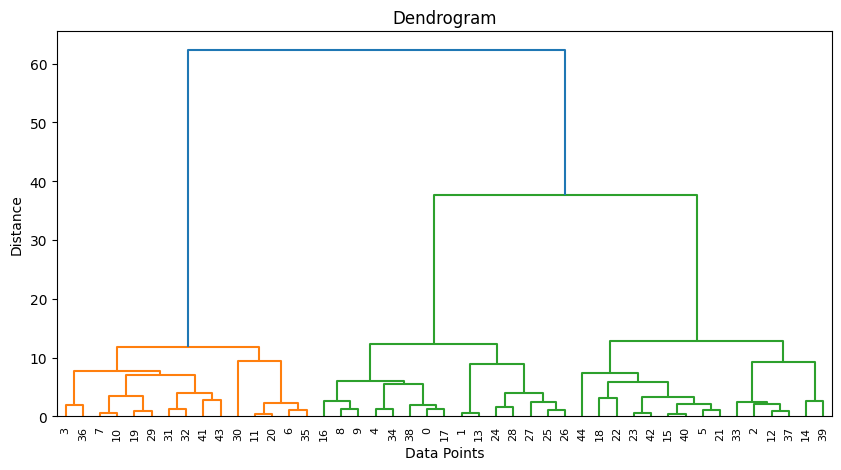

In [21]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram


# Compute the linkage matrix
from scipy.cluster.hierarchy import linkage
linkage_matrix = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix)
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()


Grupowanie aglomeracyjne jest oparte na odległości (domyślnie euklidesowej). Aby dobrze działało wymagane jest przeskalowanie zmiennych

### FeatureAgglomeration - grupowanie zastosowane dla kolumn
W celu zmniejszenia liczby zmiennych można zastosować grupowanie. Po zgrupowaniu dwie kolumny zastępuje się jedną z wartością równą średniej arytmetycznej (można użyć innej średniej lub funkcji) dla poszczególnych wierszy. 

Zauważmy, że takie grupowanie nie poprawi uogólnionych modeli liniowych (czyli np. regresji liniowej, regresji logistycznej), bo średnia artymetyczna, to operacja liniowa na zmiennych, która jest brana pod uwagę, jak wszystkie liniowe kombinacje, przy trenowaniu modelu.  

In [24]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [25]:
X = df.drop(columns='Outcome')
y = df['Outcome']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [26]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_minmax_train = scaler.fit_transform(X_train) 
X_minmax_test = scaler.transform(X_test)

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

rf = RandomForestClassifier(n_estimators = 500, n_jobs=-1, random_state=42)
rf.fit(X_train,y_train)

print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.8246753246753247
Recall: 0.6808510638297872


In [28]:
from sklearn.cluster import FeatureAgglomeration
from scipy.stats.mstats import gmean

for n in range(2,8):
    agglo = FeatureAgglomeration(n_clusters=n, pooling_func=gmean) # średnia geometryczna 
    X_agglo_train = agglo.fit_transform(X_minmax_train)
    X_agglo_test = agglo.transform(X_minmax_test)
    rf = RandomForestClassifier(n_estimators = 500, n_jobs=-1, random_state=42)
    rf.fit(X_agglo_train,y_train)
    
    print('n_clusters=',n)
    print('Accuracy:',accuracy_score(y_test,rf.predict(X_agglo_test)))
    print('Recall:',recall_score(y_test,rf.predict(X_agglo_test)))


n_clusters= 2
Accuracy: 0.7012987012987013
Recall: 0.48936170212765956
n_clusters= 3
Accuracy: 0.7792207792207793
Recall: 0.723404255319149
n_clusters= 4
Accuracy: 0.7857142857142857
Recall: 0.7021276595744681
n_clusters= 5
Accuracy: 0.7727272727272727
Recall: 0.6382978723404256
n_clusters= 6
Accuracy: 0.7792207792207793
Recall: 0.6382978723404256
n_clusters= 7
Accuracy: 0.7987012987012987
Recall: 0.6170212765957447


In [30]:
n_clusters= 7
Accuracy: 0.8116883116883117
Recall: 0.7446808510638298

In [33]:
X_agglo_train

array([[0.30385841, 0.63337414],
       [0.        , 0.46609544],
       [0.        , 0.78251655],
       ...,
       [0.        , 0.45324206],
       [0.        , 0.48882852],
       [0.        , 0.        ]])

Fajnie byłoby narysować dendrogram dla FeatureAgglomeration. Niestety nie wiem jak

Taki dendrogram można by użyć do stworzenia nowych zmiennych (feature engineering).

### Bisecting K-Means

**BisectingKMeans** jest iteracyjnym wariantem **KMeans**, wykorzystującym degromeracyjne grupowanie hierarchiczne. Zamiast tworzyć wszystkie centroidy naraz, centroidy są wybierane stopniowo na podstawie poprzedniego grupowania: **jeden z klasterów** jest dzielony na dwa nowe klastry (metodą $k$-średnich dla $k=2$), aż do osiągnięcia docelowej liczby klastrów.

BisectingKMeans jest bardziej wydajny niż KMeans, gdy liczba klastrów jest duża, ponieważ działa na coraz mniejszych podzbiorach danych w kolejnych iteracjach, podczas gdy KMeans zawsze działa na całym zbiorze danych.

Po pierwszym podziale postają dwa klastry. Teraz **jeden z nich** dzielimy na dwa mniejsze. Potrzebne jest kryterium podziału. W sklearn dla funkcji **BisectingKMeans** istnieją dwie strategie wyboru klastra do podziału:
* **bisecting_strategy='largest_cluster'** wybierany jest klaster mający najwięcej punktów
* **bisecting_strategy='biggest_inertia'** wybierany jest klaster o największej bezwładności/inercji - takie podejście daje lepsze wyniki, ale może być bardziej kosztowne obliczeniowo (szczególnie w przypadku większej liczby punktów danych).

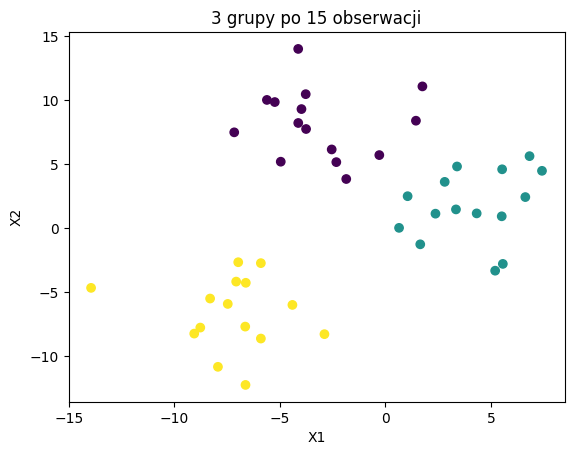

In [30]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

random_seed = 42

X, y = make_blobs(n_samples=45, centers=3, cluster_std=2.7, random_state=random_seed)


plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('3 grupy po 15 obserwacji')

# Show the plot
plt.show()

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\cluster\_bisect_k_means.py:246: UserWarning: BisectingKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


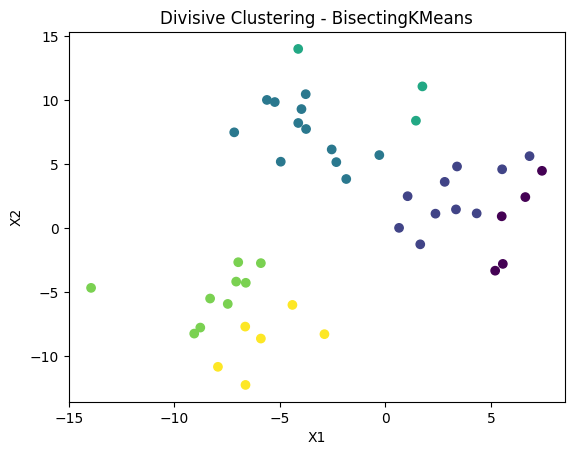

In [35]:
import matplotlib.pyplot as plt
from sklearn.cluster import BisectingKMeans


#  bisecting_strategy='biggest_inertia' (wartość domyślna), 'largest_cluster'
clustering = BisectingKMeans(n_clusters=6, bisecting_strategy='largest_cluster') 
cluster_labels = clustering.fit_predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Divisive Clustering - BisectingKMeans')

# Show the plot
plt.show()

## Model mieszaniny gaussowskiej

Niech $\mathbf{x}=\left(\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n\right)$ będzie próbką $n$ niezależnych obserwacji (liczba wierszy) z mieszaniny $k$ wielowymiarowych rozkładów normalnych o wymiarze $d$ (liczba kolumn). Niech $\mathbf{z}=\left(z_1, z_2, \ldots, z_n\right)$ będą zmiennymi ukrytymi, które określają składową, z której pochodzi obserwacja. 
$$
 X_i \mid\left(z_i=j\right) \sim \mathcal{N}_d\left(\boldsymbol{\mu}_j, \Sigma_j\right) 
$$
gdzie $j=1,2,\dots,k$ oraz $\mathrm{P}\left(z_i=j\right)=\tau_j$, $\tau_1+\dots+\tau_k=1$. 

Celem jest oszacowanie nieznanych parametrów reprezentujących wartość mieszania między Gaussami a średnimi i kowariancjami każdego z nich:
$$
\theta=\left(\boldsymbol{\tau}, \boldsymbol{\mu}_1,\dots, \boldsymbol{\mu}_k, \Sigma_1,\dots, \Sigma_k\right)
$$
gdzie jest funkcja wirygodności dla niekompletnych danych
$$
L(\theta ; \mathbf{x})=\prod_{i=1}^n \sum_{j=1}^k \tau_j f\left(\mathbf{x}_i ; \boldsymbol{\mu}_j , \Sigma_j\right)
$$
a funkcja wiarygodności dla pełnych danych to
$$
L(\theta ; \mathbf{x}, \mathbf{z})=p(\mathbf{x}, \mathbf{z} \mid \theta)=\prod_{i=1}^n \prod_{j =1}^k\left[f\left(\mathbf{x}_i ; \boldsymbol{\mu}_j, \Sigma_j\right) \tau_j\right]^{\mathbb{I}\left(z_i=j \right)}
$$
co można zapisać następująco
$$
L(\theta ; \mathbf{x}, \mathbf{z})=\exp \left\{\sum_{i=1}^n \sum_{j=1}^k \mathbb{I}\left( z_i=j\right)\left[\log \tau_j-\frac{1}{2} \log \left|\Sigma_j\right|-\frac{1}{2}\left(\mathbf{x}_i -\boldsymbol{\mu}_j\right)^{\top} \Sigma_j^{-1}\left(\mathbf{x}_i-\boldsymbol{\mu}_j\right)-\frac{d}{ 2} \log (2 \pi)\right]\right\}
$$
gdzie $\mathbb{I}$ jest funkcja charakterystyczna, a $f$ jest funkcją gęstości prawdopodobieństwa wielowymiarowego rozkładu normalnego. W ostatniej równości dla każdego $i$ jeden wskaźnik $\mathbb{I}\left(z_i=j\right)$ jest równy jeden, a pozostałe. Wewnętrzna suma składa się z jednego składnika.

##### krok E
Mając oszacowanie parametrów $\theta^{(t)}$ w kroku $t$, rozkład warunkowy $z_j$ jest dany przez twierdzenie Bayesa:
$$
T_{j, i}^{(t)}:=\mathrm{P}\left(z_i=j \mid X_i=\mathbf{x}_i ; \theta^{(t)}\right)=\frac {\tau_j^{(t)} f\left(\mathbf{x}_i ; \boldsymbol{\mu}_j^{(t)}, \Sigma_j^{(t)}\right)}{\tau_1^ {(t)} f\left(\mathbf{x}_i ; \boldsymbol{\mu}_1^{(t)}, \Sigma_1^{(t)}\right)+\dots+\tau_k^{(t)} f\left(\mathbf{x}_i ; \boldsymbol{\mu}_k^{(t)}, \Sigma_k^{(t)}\right)} .
$$
Są to dane wyjściowe kroku E.

##### krok M 
Mając $T_{j, i}^{(t)}$ maksymalizujemy następujące wyrażenie
$$
\boldsymbol{\tau}^{(t+1)} =\underset{\tau}{\arg \max }\left\{ \left[\sum_{i=1}^n T_{1, i}^{(t)}\right] \log \tau_1+\dots+\left[\sum_{i=1}^n T_{k, i}^{(t)}\right] \log \tau_k\right\}
$$
Okazuje się, że
$$
\tau_j^{(t+1)}=\frac{\sum_{i=1}^n T_{j, i}^{(t)}}{\sum_{i=1}^n\left(T_ {1, i}^{(t)}+\dots+T_{k, i}^{(t)}\right)}=\frac{1}{n} \sum_{i=1}^n T_{j, i}^{(t)}
$$
Następnie poprawiamy oszacowania $\left(\boldsymbol{\mu}_1, \Sigma_1\right)$ przez maksymalizację funkcji wiarygodności
$$
\left(\boldsymbol{\mu}_1^{(t+1)}, \Sigma_1^{(t+1)}\right) =\underset{\boldsymbol{\mu}_1, \Sigma_1}{\arg \max } \sum_{i=1}^n T_{1, i}^{(t)}\left\{-\frac {1}{2} \log \left|\Sigma_1\right|-\frac{1}{2}\left(\mathbf{x}_i-\boldsymbol{\mu}_1\right)^{\top} \Sigma_1^{-1}\left(\mathbf{x}_i-\boldsymbol{\mu}_1\right)\right\}
$$
Okazuje się, że
$$
\boldsymbol{\mu}_j^{(t+1)}=\frac{\sum_{i=1}^n T_{j, i}^{(t)} \mathbf{x}_i}{\sum_ {i=1}^n T_{j, i}^{(t)}} \text { oraz } \Sigma_1^{(t+1)}=\frac{\sum_{i=1}^n T_{ j, i}^{(t)}\left(\mathbf{x}_i-\boldsymbol{\mu}_j^{(t+1)}\right)\left(\mathbf{x}_i-\boldsymbol {\mu}_j^{(t+1)}\right)^{\top}}{\sum_{i=1}^n T_{j, i}^{(t)}}
$$
dla $j=1,\dots,k$.

##### Jak zacząć algorytm EM?
Parametr **init_params** klasy **GaussianMixture** określa metodę używaną do inicjalizacji wag, średnich i macierzy kowariancji 
* **kmeans**: inicjalizacja przy użyciu kmeans
* **k-means++**: inicjalizacja przy użyciu k-means++ 
* **random**: inicjalizacja losowa
* **random_from_data**: początkowe średnie to losowo wybrane punkty danych.

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


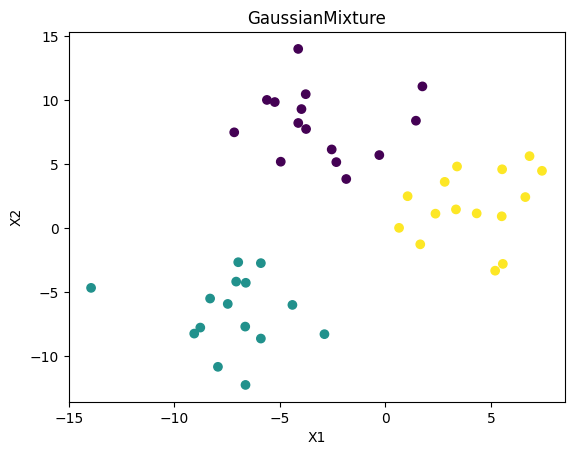

In [37]:
from sklearn.mixture import GaussianMixture
clustering = GaussianMixture(n_components=3) 
cluster_labels = clustering.fit_predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('GaussianMixture')

# Show the plot
plt.show()

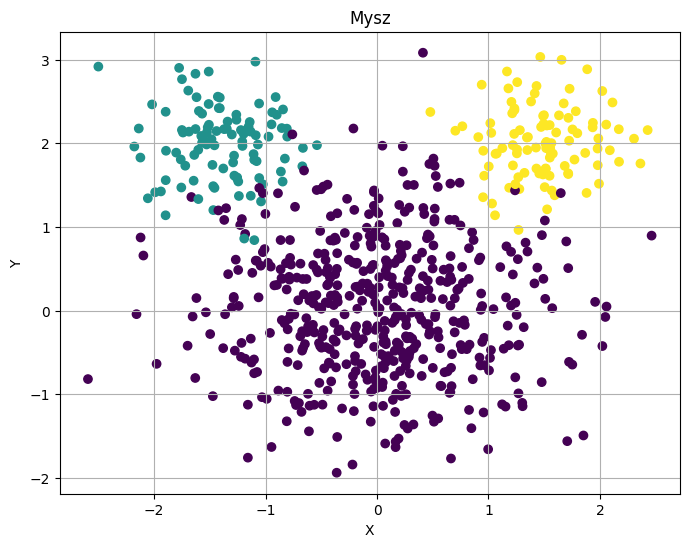

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


random_seed = 42
np.random.seed(random_seed)


centers = [(0, 0), (-1.5, 2), (1.5, 2)]
cluster_std = [0.8, 0.4, 0.4]
n_samples = [500, 100, 100]  
X_mysz, y_mysz = make_blobs(n_samples=n_samples, centers=centers, cluster_std=cluster_std, random_state=random_seed)


plt.figure(figsize=(8, 6))
plt.scatter(X_mysz[:, 0], X_mysz[:, 1], c=y_mysz, cmap='viridis')
plt.title('Mysz')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()


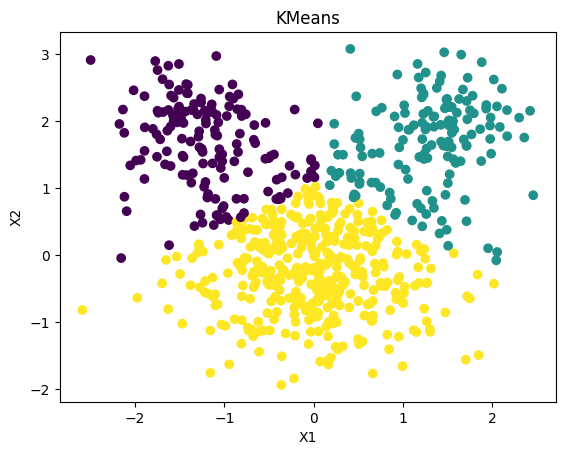

In [39]:
from sklearn.cluster import KMeans
clustering = KMeans(n_clusters=3) 
cluster_labels = clustering.fit_predict(X_mysz)

# Plot the clusters
plt.scatter(X_mysz[:, 0], X_mysz[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('KMeans')

# Show the plot
plt.show()

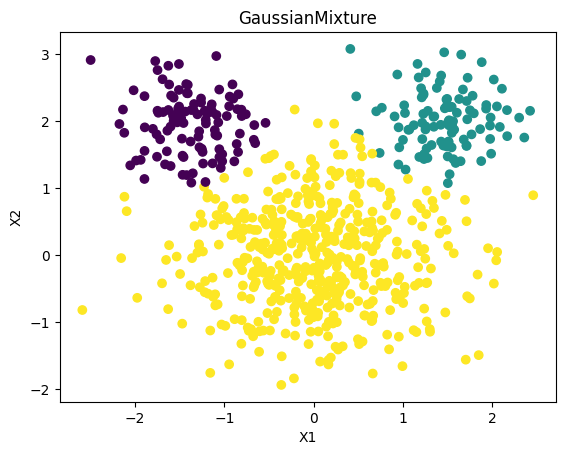

In [40]:
from sklearn.mixture import GaussianMixture
clustering = GaussianMixture(n_components=3) 
cluster_labels = clustering.fit_predict(X_mysz)

# Plot the clusters
plt.scatter(X_mysz[:, 0], X_mysz[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('GaussianMixture')

# Show the plot
plt.show()

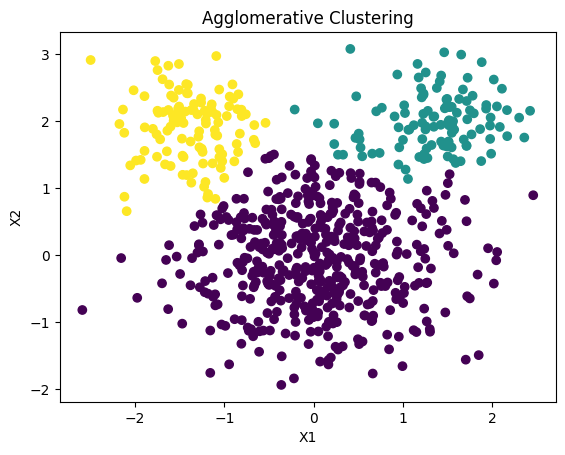

In [41]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering


# linkage = ward, ‘complete’, ‘average’, ‘single’
clustering = AgglomerativeClustering(n_clusters=3, linkage = 'ward') 
cluster_labels = clustering.fit_predict(X_mysz)

# Plot the clusters
plt.scatter(X_mysz[:, 0], X_mysz[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Agglomerative Clustering')

# Show the plot
plt.show()

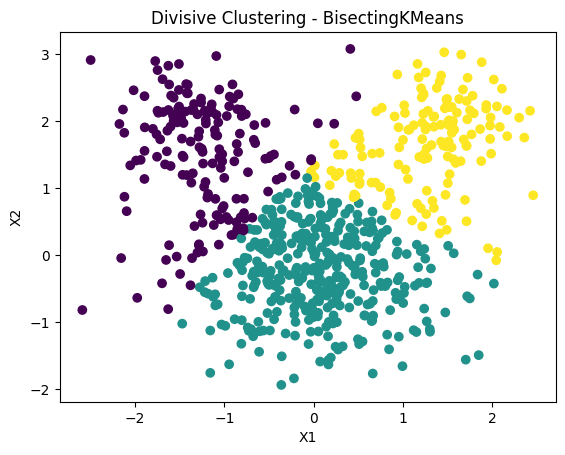

In [43]:
import matplotlib.pyplot as plt
from sklearn.cluster import BisectingKMeans


#  bisecting_strategy='biggest_inertia' (wartość domyślna), 'largest_cluster'
clustering = BisectingKMeans(n_clusters=3, bisecting_strategy='largest_cluster') 
cluster_labels = clustering.fit_predict(X_mysz)

# Plot the clusters
plt.scatter(X_mysz[:, 0], X_mysz[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Divisive Clustering - BisectingKMeans')

# Show the plot
plt.show()

## Wartości odstające

Powyższe metody nie są odporne na wartości odstające

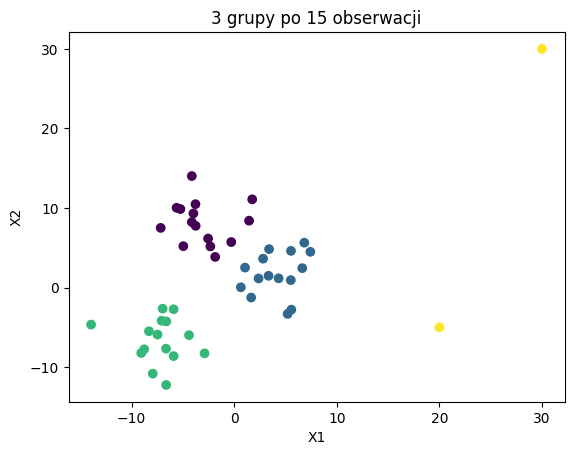

In [45]:
outliers = np.array([[30, 30], [20, -5]])  # Add two outlier points
X = np.concatenate([X, outliers])
y = np.concatenate([y, [3, 3]])  # Assign outlier points to a new cluster label


plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')

plt.title('3 grupy po 15 obserwacji')

# Show the plot
plt.show()

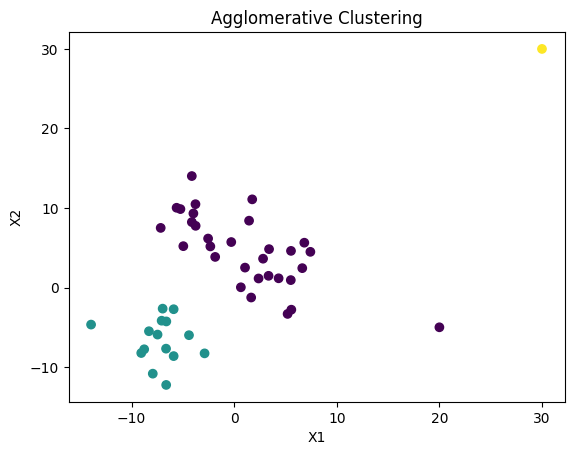

In [46]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering


# linkage = ward, ‘complete’, ‘average’, ‘single’
clustering = AgglomerativeClustering(n_clusters=3, linkage = 'ward') 
cluster_labels = clustering.fit_predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Agglomerative Clustering')

# Show the plot
plt.show()

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\cluster\_bisect_k_means.py:246: UserWarning: BisectingKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


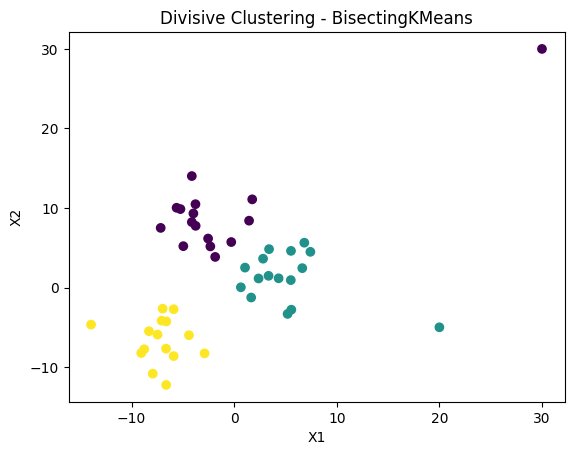

In [47]:
import matplotlib.pyplot as plt
from sklearn.cluster import BisectingKMeans


#  bisecting_strategy='biggest_inertia' (wartość domyślna), 'largest_cluster'
clustering = BisectingKMeans(n_clusters=3, bisecting_strategy='largest_cluster') 
cluster_labels = clustering.fit_predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Divisive Clustering - BisectingKMeans')

# Show the plot
plt.show()

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


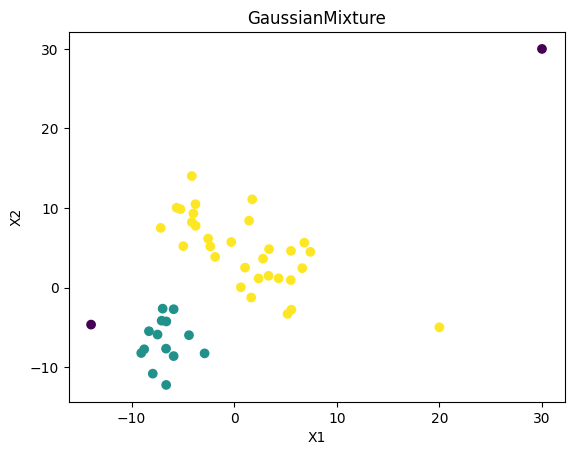

In [48]:
from sklearn.mixture import GaussianMixture
clustering = GaussianMixture(n_components=3) 
cluster_labels = clustering.fit_predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('GaussianMixture')

# Show the plot
plt.show()

### Procedura
1. Usunięcie wartości odstających
2. Przeskalowanie danych
3. Grupowanie

## Przykład i użyteczne narzędzia yellowbrick

In [49]:
import pandas as pd
df = pd.read_csv('housing_data_sample.csv', index_col='Id')
df.head()

,LotArea,YearBuilt,FullBath,TotRmsAbvGrd,GarageArea,1stFlrSF,2ndFlrSF,SalePrice
Id,,,,,,,,
1,8450,2003,2,8,548,856,854,208500
2,9600,1976,2,6,460,1262,0,181500
3,11250,2001,2,6,608,920,866,223500
4,9550,1915,1,7,642,961,756,140000
5,14260,2000,2,9,836,1145,1053,250000


In [50]:
df.shape

(1460, 8)

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings


warnings.filterwarnings("ignore")
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

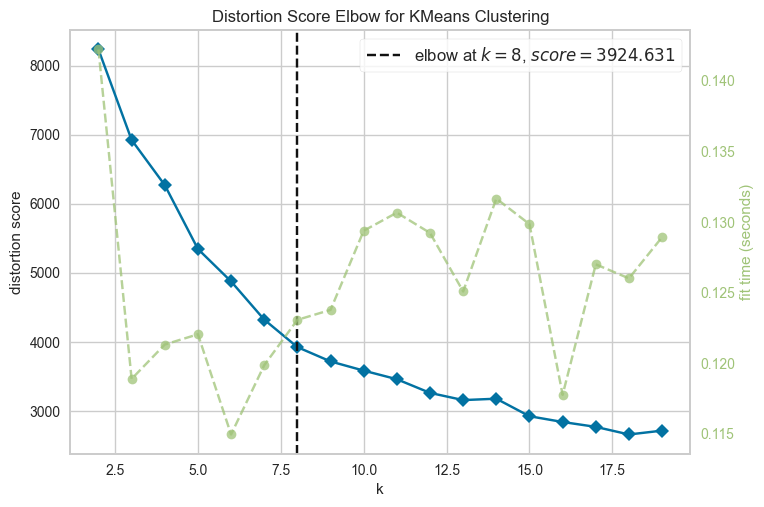

KElbowVisualizer(ax=<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>,
                 estimator=KMeans(n_clusters=19), k=(2, 20))

In [53]:
from yellowbrick.cluster.elbow import kelbow_visualizer
kelbow_visualizer(KMeans(), scaled_df, k=(2, 20))


Algorytm znajdowania optymalnego $k$ jest opisany w pracy https://raghavan.usc.edu//papers/kneedle-simplex11.pdf

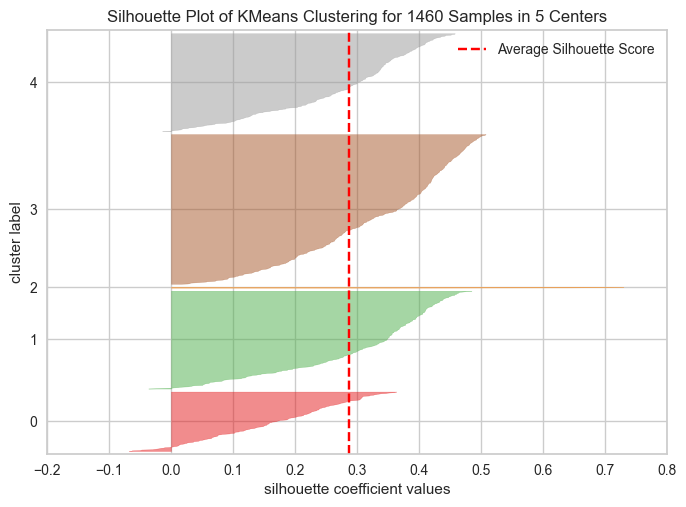

In [58]:
from yellowbrick.cluster import silhouette_visualizer
viz = silhouette_visualizer(KMeans(5, random_state=42), scaled_df)

#### Analiza klastrów

In [59]:
km = KMeans(5, random_state=42)
km.fit(scaled_df)

KMeans(n_clusters=5, random_state=42)

In [60]:
df_labels = df.copy()
df_labels['label'] = km.labels_
for label in range(5):
    print(f'cluster {label}:')
    print('wielkość klastra', len(df_labels[df_labels['label'] == label]))
    print(df_labels[df_labels['label'] == label].mean(), '\n')

cluster 0:
wielkość klastra 214
LotArea           8830.714953
YearBuilt         1929.481308
FullBath             1.392523
TotRmsAbvGrd         7.266355
GarageArea         319.056075
1stFlrSF           947.990654
2ndFlrSF           653.359813
SalePrice       139175.957944
label                0.000000
dtype: float64 

cluster 1:
wielkość klastra 352
LotArea          11513.482955
YearBuilt         1993.772727
FullBath             1.951705
TotRmsAbvGrd         6.698864
GarageArea         612.267045
1stFlrSF          1610.821023
2ndFlrSF            19.886364
SalePrice       233373.491477
label                1.000000
dtype: float64 

cluster 2:
wielkość klastra 4
LotArea         163513.50
YearBuilt         1964.75
FullBath             2.00
TotRmsAbvGrd         6.75
GarageArea         542.50
1stFlrSF          1730.75
2ndFlrSF           216.75
SalePrice       295737.50
label                2.00
dtype: float64 

cluster 3:
wielkość klastra 538
LotArea           8772.905204
YearBuilt         1

Kluster n1 1 ma średnio najniższe ceny 

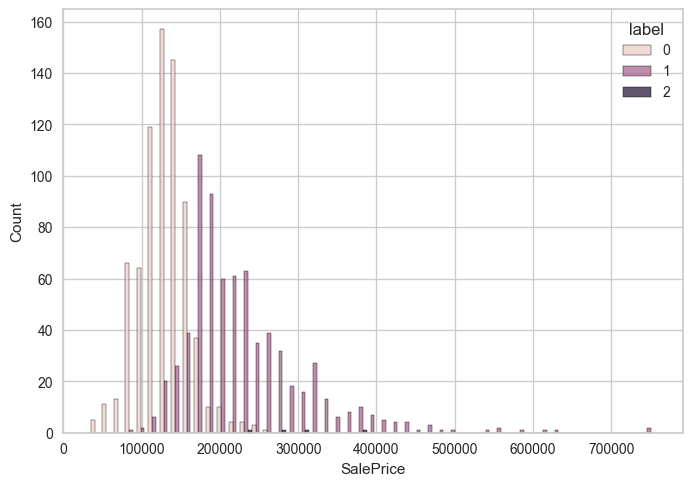

In [80]:
import seaborn as sns
sns.histplot(df_labels, x='SalePrice', hue='label', multiple='dodge')
plt.show()

Histogram pokazuje, że są wartości odstające. Kształt histogramu sugeruje, że transformacja logarytmiczna byłaby przydatna.

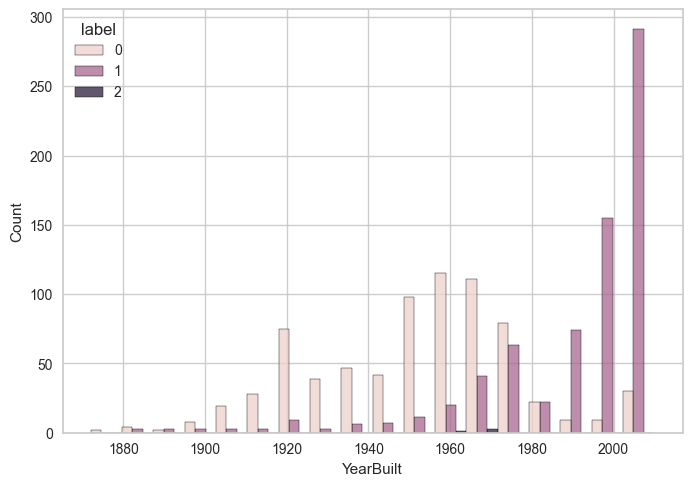

In [29]:
sns.histplot(df_labels, x='YearBuilt', hue='label', multiple='dodge')
plt.show()

Można tak dalej analizować zmienne z uwzględnieniem klastrów. W ten sposób szukamy cech poszczególnych klastrów. 

In [81]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=7)
ac.fit(scaled_df)

AgglomerativeClustering(n_clusters=7)

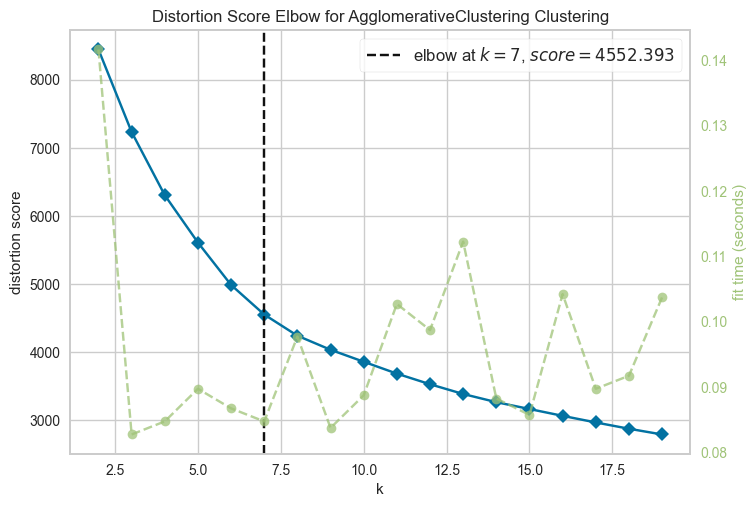

In [82]:
viz = kelbow_visualizer(AgglomerativeClustering(),
                        scaled_df,
                        k=(2, 20),
                        show=False)

Text(0, 0.5, 'depth')

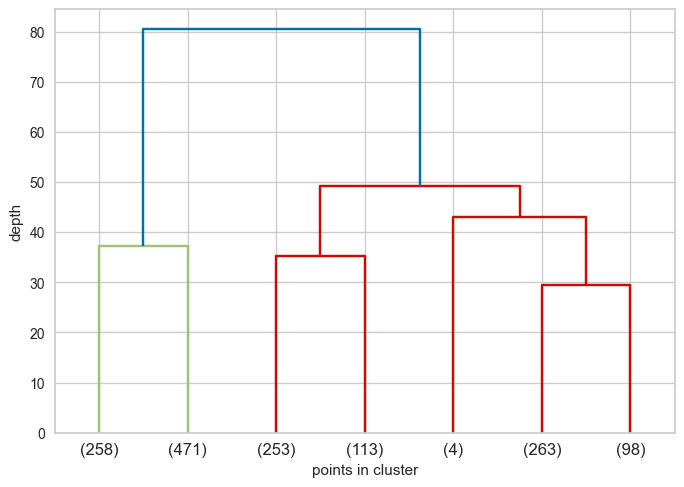

In [65]:
from scipy.cluster.hierarchy import dendrogram, linkage
dendrogram(linkage(scaled_df, method ='ward'), truncate_mode='lastp', p=7)
plt.xlabel('points in cluster')
plt.ylabel('depth')

In [86]:
n_clusters = 3

ac = AgglomerativeClustering(n_clusters=n_clusters)
ac.fit(scaled_df)

df_labels = df.copy()
df_labels['label'] = ac.labels_
for label in range(3):
    print(f'cluster {label}:')
    print('cluster size:',len(df_labels[df_labels['label'] == label]), '\n')
    print(df_labels[df_labels['label'] == label].mean(), '\n')
    

cluster 0:
cluster size: 365 

LotArea          13038.068493
YearBuilt         1991.975342
FullBath             1.994521
TotRmsAbvGrd         6.652055
GarageArea         587.745205
1stFlrSF          1578.553425
2ndFlrSF            19.627397
SalePrice       224790.912329
label                0.000000
dtype: float64 

cluster 1:
cluster size: 729 

LotArea           9150.045267
YearBuilt         1951.456790
FullBath             1.094650
TotRmsAbvGrd         5.777778
GarageArea         371.445816
1stFlrSF           998.599451
2ndFlrSF           222.144033
SalePrice       134046.263374
label                1.000000
dtype: float64 

cluster 2:
cluster size: 366 

LotArea          10724.838798
YearBuilt         1990.076503
FullBath             2.073770
TotRmsAbvGrd         7.857923
GarageArea         560.765027
1stFlrSF          1074.546448
2ndFlrSF           922.136612
SalePrice       230536.986339
label                2.000000
dtype: float64 

